# Power System Load Type Classification - Assignment 2

This notebook builds a machine learning model that predicts the `Load_Type` of a power system
(`Light_Load`, `Medium_Load` or `Maximum_Load`) from 15-minute electrical measurements and their timestamps.
The final model is evaluated on the **last month of data (December 2018)**, which is never used for training or model selection.

## 1. Problem Statement and Objective

**Problem.** A power system records electricity measurements every 15 minutes. Each record is labelled with how heavily
the system was loaded at that time. We want to predict this label automatically.

**Objective.** Build a 3-class classification model for `Load_Type`:

| Class | Meaning |
|---|---|
| `Light_Load` | Low demand on the system |
| `Medium_Load` | Moderate demand |
| `Maximum_Load` | Peak demand |

**Evaluation requirement (from the problem statement).** The last month of data is the test set. This simulates a real
deployment: the model learns from the past and is judged on future data it has never seen. Because of this, a random
`train_test_split` is **not** appropriate, since it would mix future records into training.

**Metrics.** Accuracy, precision, recall and F1-score. Because the classes are not equally frequent, macro-averaged F1
(which treats each class equally) will be the main metric for comparing models.

**Data description provided with the assignment vs. the actual file.** The description lists Date, Usage_kWh, lagging and
leading reactive power, CO2 (described as ppm), NSM and Load_Type. The actual file differs in a few ways, which are
checked in this notebook:
- The timestamps are 15-minute readings throughout the year, not one reading on the first of each month.
- The CO2 column is named `CO2(tCO2)` (tonnes of CO2), not ppm.
- There are two extra columns: lagging and leading current power factor.

In [419]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.13
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn: 1.9.1
Matplotlib: 3.11.2


In [73]:
# Core libraries for this stage
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings so wide tables are readable in the notebook
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
print("display.max_columns", pd.get_option("display.max_columns"))
print("display.width", pd.get_option("display.width"))

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

display.max_columns 50
display.width 200
pandas version: 3.0.6
numpy version: 2.5.3


## 2. Dataset Loading

The dataset is a single CSV file, `data/load_data.csv`, stored in the `data` folder next to this notebook.
We keep an untouched copy (`df_raw`) so we can always compare the cleaned data with the original.

In [74]:
DATA_PATH = Path("data") / "load_data.csv"

# Fail early with a clear message if the file is not where we expect it
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. "
        "Make sure the 'data' folder is in the same folder as this notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Rows: 35,041
Columns: 9


## 3. Dataset Inspection

Before changing anything, we look at the data: the first and last rows, column names, and summary statistics.
This tells us what each column contains and reveals obvious problems.

In [75]:
df_raw.head(10)

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load
5,01-01-2018 01:30,3.280000,3.56,0.0,0.0,67.760000,100.0,5400.000000,Light_Load
6,01-01-2018 01:45,3.600000,4.14,0.0,0.0,65.620000,100.0,6300.000000,Light_Load
7,01-01-2018 02:00,3.600000,4.28,0.0,0.0,64.370000,100.0,16589.736453,Light_Load
8,01-01-2018 02:15,5.930615,3.64,0.0,0.0,66.940000,100.0,8100.000000,Light_Load
9,01-01-2018 02:30,3.780000,4.72,0.0,0.0,62.510000,100.0,9000.000000,Light_Load


In [76]:
# The end of the file is worth checking separately: problems are often appended at the end
df_raw.tail(5)

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
35036,31-12-2018 23:15,3.74,3.74,0.000000,0.0,70.710000,100.00,83700.000000,Light_Load
35037,31-12-2018 23:30,3.78,3.17,0.070000,0.0,76.620000,99.98,157160.395291,Light_Load
35038,31-12-2018 23:45,3.78,3.06,0.110000,0.0,187.054285,99.96,85500.000000,Light_Load
35039,31-12-2018 00:00,3.67,3.02,0.174801,0.0,77.220000,NaN,0.000000,Light_Load
35040,31-12-2018 20:00,NaN,0.00,20.100000,0.0,217.273470,20.19,72000.000000,Light_Load


### Renaming columns

Some original column names contain dots, parentheses and inconsistent spelling
(e.g. `Lagging_Current_Reactive.Power_kVarh`). Short, consistent names make the code easier to read and less error-prone.
Only the names change; the values are untouched.

In [77]:
column_names = {
    "Date_Time": "date_time",
    "Usage_kWh": "usage_kwh",
    "Lagging_Current_Reactive.Power_kVarh": "lagging_reactive_kvarh",
    "Leading_Current_Reactive_Power_kVarh": "leading_reactive_kvarh",
    "CO2(tCO2)": "co2_tco2",
    "Lagging_Current_Power_Factor": "lagging_power_factor",
    "Leading_Current_Power_Factor": "leading_power_factor",
    "NSM": "nsm",
    "Load_Type": "load_type",
}

# Safety check: every expected column must exist in the file
missing_cols = set(column_names) - set(df_raw.columns)
assert not missing_cols, f"Expected columns not found: {missing_cols}"

df = df_raw.rename(columns=column_names).copy()
df.columns.tolist()

['date_time',
 'usage_kwh',
 'lagging_reactive_kvarh',
 'leading_reactive_kvarh',
 'co2_tco2',
 'lagging_power_factor',
 'leading_power_factor',
 'nsm',
 'load_type']

In [78]:
# Summary statistics for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
usage_kwh,33482.0,30.873061,41.415015,0.0,3.310,5.29,53.560000,435.019069
lagging_reactive_kvarh,34165.0,14.704573,20.342721,0.0,2.340,5.18,23.510000,262.630718
leading_reactive_kvarh,33885.0,4.386097,9.090181,0.0,0.000,0.00,2.298558,78.809000
co2_tco2,34586.0,0.012947,0.019726,0.0,0.000,0.00,0.020000,0.188166
lagging_power_factor,34691.0,90.740871,39.745395,0.0,66.295,90.08,100.000000,299.996814
leading_power_factor,33570.0,94.926552,49.826872,0.0,99.800,100.00,100.000000,299.969494
nsm,34586.0,48013.664032,34046.492333,0.0,22500.000,45000.00,68400.000000,248821.810465


In [79]:
# The target column: which labels exist and how often?
df["load_type"].value_counts(dropna=False)

load_type
Light_Load      18073
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

### Sanity checks on value ranges

Summary statistics can hide invalid values. Two checks based on domain knowledge:

- **Power factor** is a percentage, so it must be between 0 and 100.
- **NSM** (Number of Seconds from Midnight) is fully determined by the time of day: it must be a whole multiple of 900
  (15 minutes) between 0 and 85,500. We compare it with the value computed from the timestamp later, in Section 4.

Here we only **count** problems. Fixing them is a cleaning decision made in Stage 2, after the timestamps are parsed.

In [80]:
numeric_cols = [
    "usage_kwh", "lagging_reactive_kvarh", "leading_reactive_kvarh", "co2_tco2",
    "lagging_power_factor", "leading_power_factor", "nsm",
]

range_checks = pd.DataFrame({
    "negative_values": (df[numeric_cols] < 0).sum(),
    "max_value": df[numeric_cols].max(),
})
range_checks.loc["lagging_power_factor", "values_above_100"] = (df["lagging_power_factor"] > 100).sum()
range_checks.loc["leading_power_factor", "values_above_100"] = (df["leading_power_factor"] > 100).sum()
range_checks.loc["nsm", "non_integer_values"] = (df["nsm"].dropna() % 1 != 0).sum()
range_checks.loc["nsm", "values_above_86400"] = (df["nsm"] > 86_400).sum()
range_checks

,negative_values,max_value,values_above_100,non_integer_values,values_above_86400
usage_kwh,0,435.019069,NaN,NaN,NaN
lagging_reactive_kvarh,0,262.630718,NaN,NaN,NaN
leading_reactive_kvarh,0,78.809000,NaN,NaN,NaN
co2_tco2,0,0.188166,NaN,NaN,NaN
lagging_power_factor,0,299.996814,3226.0,NaN,NaN
leading_power_factor,0,299.969494,2685.0,NaN,NaN
nsm,0,248821.810465,NaN,3414.0,1773.0


## 4. Data Types

Machine learning code needs each column stored with the right type. The date/time column is currently plain text,
so pandas cannot sort it, extract the hour, or select a month from it.

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date_time               35041 non-null  str    
 1   usage_kwh               33482 non-null  float64
 2   lagging_reactive_kvarh  34165 non-null  float64
 3   leading_reactive_kvarh  33885 non-null  float64
 4   co2_tco2                34586 non-null  float64
 5   lagging_power_factor    34691 non-null  float64
 6   leading_power_factor    33570 non-null  float64
 7   nsm                     34586 non-null  float64
 8   load_type               35041 non-null  str    
dtypes: float64(7), str(2)
memory usage: 2.4 MB


### Parsing the timestamp

The format in the file is day-month-year, e.g. `01-01-2018 00:15`. We give pandas the exact format
(`%d-%m-%Y %H:%M`) instead of letting it guess, because guessing could mix up day and month
(e.g. `01-02-2018` could be read as 2 January or 1 February).

In [82]:
df["timestamp"] = pd.to_datetime(df["date_time"], format="%d-%m-%Y %H:%M", errors="coerce")

print("Timestamps that failed to parse:", df["timestamp"].isna().sum())
print("Earliest timestamp:", df["timestamp"].min())
print("Latest timestamp:  ", df["timestamp"].max())
print("Is the file already in time order?", df["timestamp"].is_monotonic_increasing)

Timestamps that failed to parse: 0
Earliest timestamp: 2018-01-01 00:00:00
Latest timestamp:   2018-12-31 23:45:00
Is the file already in time order? False


### The midnight timestamp issue

The file is **not** in time order according to the parsed timestamps. Looking at the end of the first day shows why:
the reading stamped `01-01-2018 00:00` comes **after** `01-01-2018 23:45`.

In [83]:
df.loc[93:97, ["date_time", "timestamp", "nsm", "load_type"]]

,date_time,timestamp,nsm,load_type
93,01-01-2018 23:30,2018-01-01 23:30:00,84600.0,Light_Load
94,01-01-2018 23:45,2018-01-01 23:45:00,85500.0,Light_Load
95,01-01-2018 00:00,2018-01-01 00:00:00,0.0,Light_Load
96,02-01-2018 00:15,2018-01-02 00:15:00,900.0,Light_Load
97,02-01-2018 00:30,2018-01-02 00:30:00,1800.0,Light_Load


Each reading summarises the **15 minutes ending** at its timestamp: the first row of the file, `00:15`, covers 00:00–00:15.
So the row stamped `01-01-2018 00:00` is really the final reading of 1 January (covering 23:45–24:00). The date is
written as the day the interval belongs to, but parsed literally it would be placed at the start of that day.

If we ignored this, these rows would get the wrong position in time, and later the wrong hour and weekday features.

**Fix.** We create `interval_start`, the moment each 15-minute interval begins:
1. For `00:00` rows, the true end time is midnight of the **next** day, so we add one day.
2. Subtract 15 minutes from every end time to get the interval start.

After this, every row's `interval_start` falls on the date written in the file. We **verify** that below rather than assume it.

In [84]:
is_midnight = (df["timestamp"].dt.hour == 0) & (df["timestamp"].dt.minute == 0)
print("Rows stamped 00:00:", is_midnight.sum())

interval_end = df["timestamp"] + pd.to_timedelta(is_midnight.astype(int), unit="D")
df["interval_start"] = interval_end - pd.Timedelta(minutes=15)

# Verification: interval_start must be on the same calendar date that is written in the file
same_date = (df["interval_start"].dt.date == df["timestamp"].dt.date)
print("Rows whose interval_start date differs from the written date:", (~same_date).sum())

df.loc[93:97, ["date_time", "interval_start", "load_type"]]

Rows stamped 00:00: 365
Rows whose interval_start date differs from the written date: 0


,date_time,interval_start,load_type
93,01-01-2018 23:30,2018-01-01 23:15:00,Light_Load
94,01-01-2018 23:45,2018-01-01 23:30:00,Light_Load
95,01-01-2018 00:00,2018-01-01 23:45:00,Light_Load
96,02-01-2018 00:15,2018-01-02 00:00:00,Light_Load
97,02-01-2018 00:30,2018-01-02 00:15:00,Light_Load


### Converting the target to a categorical type

`load_type` has only three possible values. Storing it as an **ordered** categorical type records that
Light < Medium < Maximum and keeps the classes in this logical order in all later tables and plots.

In [85]:
LOAD_ORDER = ["Light_Load", "Medium_Load", "Maximum_Load"]

unexpected = set(df["load_type"].unique()) - set(LOAD_ORDER)
assert not unexpected, f"Unexpected labels found: {unexpected}"

df["load_type"] = pd.Categorical(df["load_type"], categories=LOAD_ORDER, ordered=True)
df.dtypes

date_time                            str
usage_kwh                        float64
lagging_reactive_kvarh           float64
leading_reactive_kvarh           float64
co2_tco2                         float64
lagging_power_factor             float64
leading_power_factor             float64
nsm                              float64
load_type                       category
timestamp                 datetime64[us]
interval_start            datetime64[us]
dtype: object

## 5. Missing Values

Most models cannot handle missing values, so we must know where they are.

**Important:** in this section we only *measure* missing values. We do **not** fill them yet. Filling (imputation) uses
statistics such as the median; if those were computed on the whole dataset they would include December, and information
from the test month would leak into training. Imputation will therefore be done inside a scikit-learn pipeline that is
fitted on training data only (Stage 3).

In [86]:
missing = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)
missing

,missing_count,missing_percent
Usage_kWh,1559,4.45
Leading_Current_Power_Factor,1471,4.20
Leading_Current_Reactive_Power_kVarh,1156,3.30
Lagging_Current_Reactive.Power_kVarh,876,2.50
CO2(tCO2),455,1.30
NSM,455,1.30
Lagging_Current_Power_Factor,350,1.00
Date_Time,0,0.00
Load_Type,0,0.00


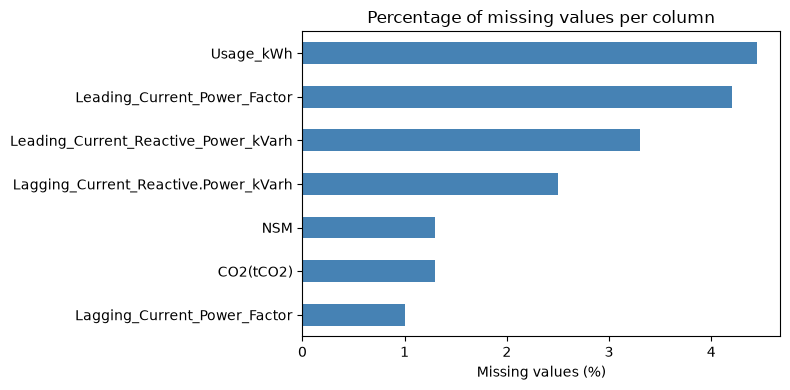

In [87]:
plot_data = missing.loc[missing["missing_count"] > 0, "missing_percent"].sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
plot_data.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Missing values (%)")
ax.set_title("Percentage of missing values per column")
plt.tight_layout()
plt.show()

### Are missing values spread evenly over time?

If missing values were concentrated in one month (for example the test month), that would affect how we evaluate the model.

In [88]:
missing_by_month = (
    df[numeric_cols]
    .isna()
    .groupby(df["interval_start"].dt.to_period("M"))
    .sum()
)
missing_by_month

,usage_kwh,lagging_reactive_kvarh,leading_reactive_kvarh,co2_tco2,lagging_power_factor,leading_power_factor,nsm
interval_start,,,,,,,
2018-01,128,78,90,33,36,136,36
2018-02,120,59,91,42,31,101,35
2018-03,132,69,85,33,40,138,40
2018-04,132,78,92,35,29,134,45
2018-05,120,79,101,43,25,115,39
2018-06,120,80,95,40,34,113,39
2018-07,142,76,97,35,25,125,27
2018-08,115,70,101,45,26,126,30
2018-09,119,59,111,40,27,113,41


In [89]:
# How many columns are missing in the same row?
missing_per_row = df[numeric_cols].isna().sum(axis=1)
missing_per_row.value_counts().sort_index().rename("number_of_rows").rename_axis("missing_columns_in_row")

missing_columns_in_row
0    29178
1     5422
2      424
3       16
4        1
Name: number_of_rows, dtype: int64

## 6. Duplicate Records

Duplicates can bias a model (the same information counted twice) and, if a row appears in both training and test data,
they cause leakage. We check two kinds:

1. **Exact duplicates:** rows identical in every column.
2. **Duplicate timestamps:** two rows for the same 15-minute interval. The data should contain exactly one reading per interval.

In [90]:
print("Exact duplicate rows:", df_raw.duplicated().sum())

dup_mask = df["interval_start"].duplicated(keep=False)
print("Rows sharing a timestamp with another row:", dup_mask.sum())

df.loc[dup_mask, ["date_time"] + numeric_cols + ["load_type"]]

Exact duplicate rows: 0
Rows sharing a timestamp with another row: 2


,date_time,usage_kwh,lagging_reactive_kvarh,leading_reactive_kvarh,co2_tco2,lagging_power_factor,leading_power_factor,nsm,load_type
35023,31-12-2018 20:00,4.14,0.0,20.09,0.0,100.00000,20.18,72000.0,Light_Load
35040,31-12-2018 20:00,NaN,0.0,20.10,0.0,217.27347,20.19,72000.0,Light_Load


### Duplicate Record Handling

One duplicate 15-minute interval was identified in the dataset. The duplicate record was removed while retaining the first occurrence.

This ensures that each 15-minute time interval is represented only once in the dataset.

In [91]:
rows_before = len(df)

df = (
    df.drop_duplicates(subset="interval_start", keep="first")
      .sort_values("interval_start")
      .reset_index(drop=True)
)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {len(df):,}")
print("Remaining duplicate timestamps:", df["interval_start"].duplicated().sum())

Rows before: 35,041
Rows after:  35,040
Remaining duplicate timestamps: 0


### Final check: is the time series complete and regular?

A full year (2018 is not a leap year) at 15-minute intervals should have 365 × 96 = 35,040 rows, each exactly 15 minutes apart.

In [92]:
expected_rows = 365 * 96
gaps = df["interval_start"].diff().dropna().value_counts()

print("Expected rows:", expected_rows)
print("Actual rows:  ", len(df))
print("Sorted in time order:", df["interval_start"].is_monotonic_increasing)
print("\nTime differences between consecutive rows:")
print(gaps)

Expected rows: 35040
Actual rows:   35040
Sorted in time order: True

Time differences between consecutive rows:
interval_start
0 days 00:15:00    35039
Name: count, dtype: int64


### Stage 1 summary

At this stage, the dataset has been loaded and inspected for its structure, data types, missing values, duplicate records, and basic data-quality issues.

The timestamp column has been parsed using the correct date-time format, and the dataset structure and temporal ordering have been examined.

The detailed data-cleaning and feature-engineering steps are performed in the following sections.


## 7. Data Cleaning and Exploratory Data Analysis

### 7.1 Validating NSM

The recorded NSM (Number of Seconds from Midnight) represents the time indicated by the recorded timestamp. Because the 00:00 records represent the final 15-minute interval of the written date, NSM is validated against the timestamp column rather than interval_start.

The expected NSM is calculated from the hour, minute, and second of the recorded timestamp. Missing or inconsistent NSM values are then replaced with this deterministic timestamp-derived value.

In [93]:
# Reload the original dataset and rebuild the cleaned dataframe
df_raw = pd.read_csv(DATA_PATH)

df = df_raw.rename(columns=column_names).copy()

# Parse timestamp
df["timestamp"] = pd.to_datetime(
    df["date_time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# Create the actual 15-minute interval start
is_midnight = (
    (df["timestamp"].dt.hour == 0)
    & (df["timestamp"].dt.minute == 0)
)

interval_end = df["timestamp"] + pd.to_timedelta(
    is_midnight.astype(int), unit="D"
)

df["interval_start"] = interval_end - pd.Timedelta(minutes=15)

# Target as ordered categorical
df["load_type"] = pd.Categorical(
    df["load_type"],
    categories=LOAD_ORDER,
    ordered=True
)

# Remove the duplicate interval and sort chronologically
df = (
    df.drop_duplicates(subset="interval_start", keep="first")
      .sort_values("interval_start")
      .reset_index(drop=True)
)

print("Rows after rebuilding:", len(df))
print("Duplicate intervals:", df["interval_start"].duplicated().sum())

Rows after rebuilding: 35040
Duplicate intervals: 0


In [94]:
# Calculate the expected NSM directly from the recorded timestamp
expected_nsm_from_timestamp = (
    df["timestamp"].dt.hour * 3600
    + df["timestamp"].dt.minute * 60
    + df["timestamp"].dt.second
)

nsm_invalid = (
    df["nsm"].isna()
    | (df["nsm"] != expected_nsm_from_timestamp)
)

print("Missing or inconsistent NSM values:", nsm_invalid.sum())

df.loc[nsm_invalid, "nsm"] = expected_nsm_from_timestamp[nsm_invalid]

nsm_check = (
    df["nsm"] ==
    (
        df["timestamp"].dt.hour * 3600
        + df["timestamp"].dt.minute * 60
        + df["timestamp"].dt.second
    )
)

print("Missing NSM values after correction:", df["nsm"].isna().sum())
print("Inconsistent NSM values after correction:", (~nsm_check).sum())

Missing or inconsistent NSM values: 3869
Missing NSM values after correction: 0
Inconsistent NSM values after correction: 0


### 7.2 Power Factor Validation

Power factor is expected to be a percentage between 0 and 100.

The dataset contains two power-factor measurements:
- `lagging_power_factor`
- `leading_power_factor`

We first identify missing and out-of-range values. Invalid values will be treated as missing and handled later through training-data-only preprocessing.

In [95]:
# Check missing and out-of-range power-factor values
pf_cols = [
    "lagging_power_factor",
    "leading_power_factor"
]

pf_check = pd.DataFrame({
    "missing": df[pf_cols].isna().sum(),
    "below_0": (df[pf_cols] < 0).sum(),
    "above_100": (df[pf_cols] > 100).sum(),
})

pf_check

,missing,below_0,above_100
lagging_power_factor,350,0,3225
leading_power_factor,1471,0,2685


In [96]:
# Treat out-of-range power-factor values as missing
for col in pf_cols:
    invalid = (df[col] < 0) | (df[col] > 100)
    df.loc[invalid, col] = np.nan

# Verify the cleaning
pf_check_after = pd.DataFrame({
    "missing": df[pf_cols].isna().sum(),
    "below_0": (df[pf_cols] < 0).sum(),
    "above_100": (df[pf_cols] > 100).sum(),
})

pf_check_after

,missing,below_0,above_100
lagging_power_factor,3575,0,0
leading_power_factor,4156,0,0


In [97]:
# Check the remaining numerical measurements for negative values
measurement_cols = [
    "usage_kwh",
    "lagging_reactive_kvarh",
    "leading_reactive_kvarh",
    "co2_tco2"
]

negative_check = pd.DataFrame({
    "negative_values": (df[measurement_cols] < 0).sum(),
    "missing_values": df[measurement_cols].isna().sum(),
})

negative_check

,negative_values,missing_values
usage_kwh,0,1558
lagging_reactive_kvarh,0,876
leading_reactive_kvarh,0,1156
co2_tco2,0,455


### 7.3 Checking Numerical Measurements

The main numerical measurements were checked for negative values.

No negative values were found in `usage_kwh`, `lagging_reactive_kvarh`, `leading_reactive_kvarh`, or `co2_tco2`. Therefore, no negative-value correction or row removal is required.

Some missing values are present in these measurements. These will be handled later during model preprocessing using imputation fitted only on the training data.

In [98]:
# Check the distribution of the target classes
class_counts = df["load_type"].value_counts().reindex(LOAD_ORDER)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": (class_counts / len(df) * 100).round(2)
})

class_distribution

,count,percentage
load_type,,
Light_Load,18072,51.58
Medium_Load,9696,27.67
Maximum_Load,7272,20.75


### 7.4 Target Class Distribution

The target variable contains three load categories:

- `Light_Load`: 51.58%
- `Medium_Load`: 27.67%
- `Maximum_Load`: 20.75%

The classes are moderately imbalanced, with `Light_Load` being the most frequent class and `Maximum_Load` the least frequent. Therefore, accuracy alone may not fully represent model performance. Macro-averaged precision, recall, and F1-score will also be considered, with Macro F1 used as the primary metric for model comparison.

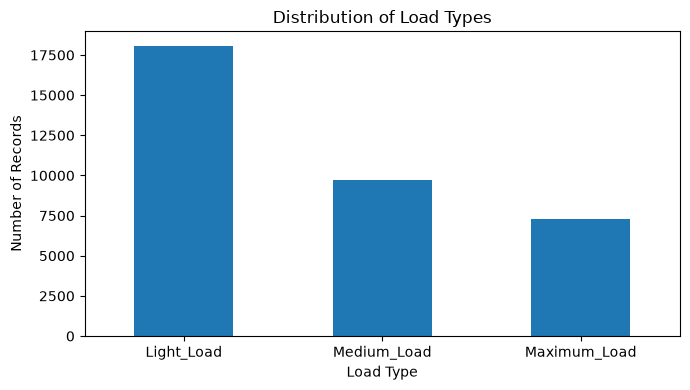

In [99]:
# Visualize the target class distribution
fig, ax = plt.subplots(figsize=(7, 4))

class_counts.plot(kind="bar", ax=ax)

ax.set_xlabel("Load Type")
ax.set_ylabel("Number of Records")
ax.set_title("Distribution of Load Types")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 7.5 Numerical Feature Distributions

The distributions of the main numerical measurements are examined to understand their ranges, spread, skewness, and possible extreme values.

These measurements will later be used as input features for the classification models.

In [100]:
# Summary statistics for the numerical measurements
df[measurement_cols + pf_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
usage_kwh,33482.0,30.873061,41.415015,0.0,3.3100,5.29,53.560000,435.019069
lagging_reactive_kvarh,34164.0,14.705004,20.342863,0.0,2.3400,5.18,23.510000,262.630718
leading_reactive_kvarh,33884.0,4.385633,9.089914,0.0,0.0000,0.00,2.297438,78.809000
co2_tco2,34585.0,0.012947,0.019726,0.0,0.0000,0.00,0.020000,0.188166
lagging_power_factor,31465.0,80.552643,18.918184,0.0,63.2700,87.89,98.890000,100.000000
leading_power_factor,30884.0,83.680636,30.591689,0.0,98.9475,100.00,100.000000,100.000000


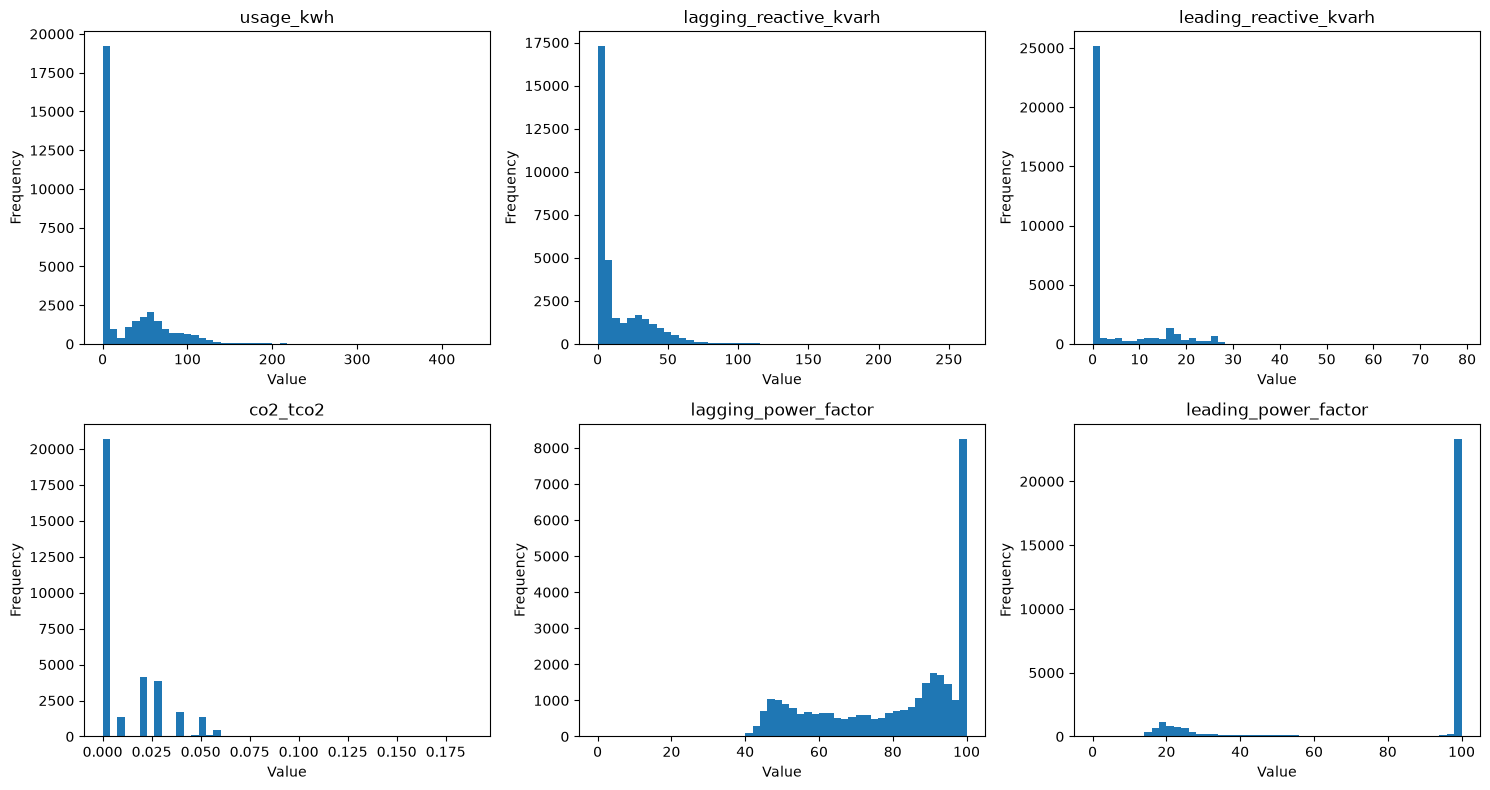

In [101]:
# Visualize distributions of the numerical features
features_to_plot = measurement_cols + pf_cols

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, features_to_plot):
    ax.hist(df[col].dropna(), bins=50)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 7.6 Numerical Features by Load Type

The numerical features are compared across the three load categories to identify differences in their distributions.

This helps determine whether the electrical measurements contain useful information for distinguishing `Light_Load`, `Medium_Load`, and `Maximum_Load`.

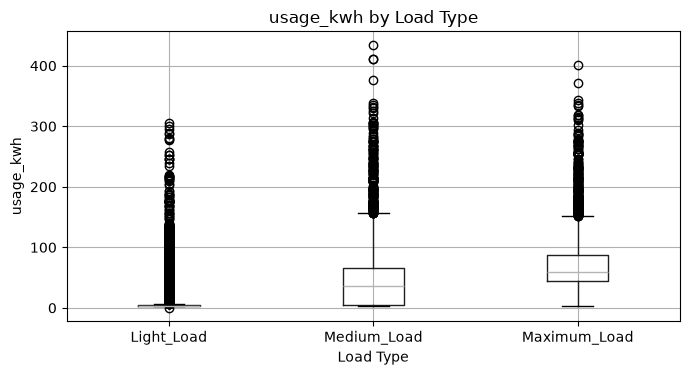

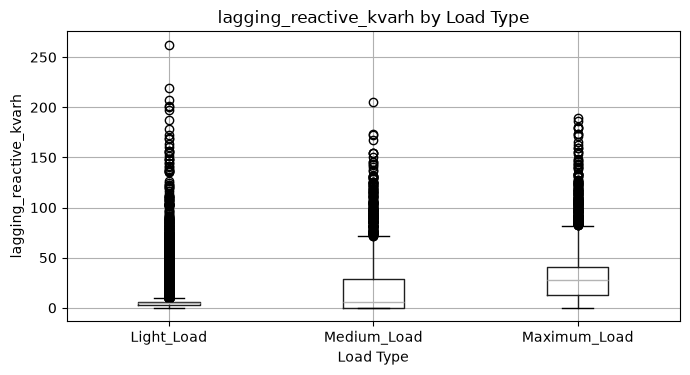

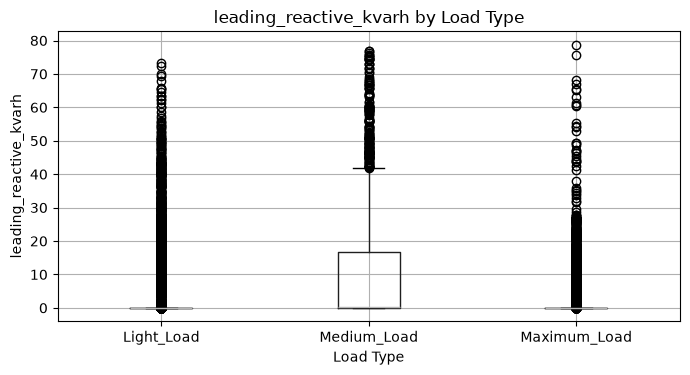

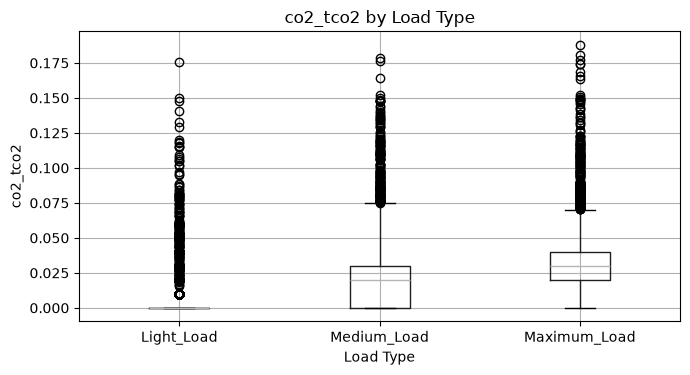

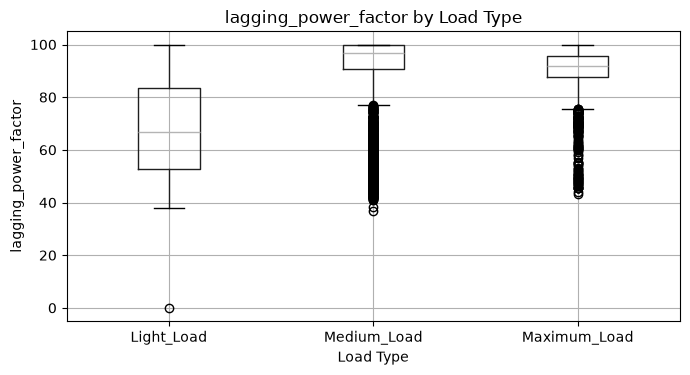

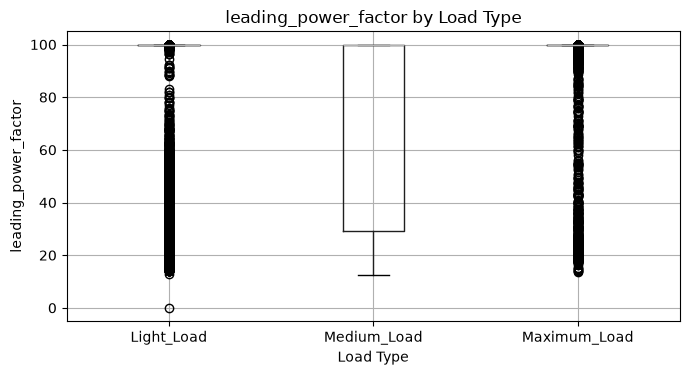

In [102]:
# Compare numerical features across load types
for col in measurement_cols + pf_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    
    df.boxplot(column=col, by="load_type", ax=ax)
    
    ax.set_title(f"{col} by Load Type")
    ax.set_xlabel("Load Type")
    ax.set_ylabel(col)
    
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

### 7.7 Load Type by Hour of Day

The distribution of load types is analyzed across different hours of the day. This helps identify whether certain load categories are more common during particular periods.

The timestamp-derived information can therefore provide useful predictive features for the classification model.

In [103]:
# Create hour and day-of-week features for EDA
df["hour"] = df["interval_start"].dt.hour
df["day_of_week"] = df["interval_start"].dt.dayofweek
df["month"] = df["interval_start"].dt.month

# Count each load type by hour
hour_load = pd.crosstab(df["hour"], df["load_type"])

hour_load

load_type,Light_Load,Medium_Load,Maximum_Load
hour,,,
0,1460,0,0
1,1460,0,0
2,1460,0,0
3,1460,0,0
4,1460,0,0
5,1460,0,0
6,1460,0,0
7,1460,0,0
8,1460,0,0


### 7.8 Load Type Distribution by Hour

The distribution of load types across the hours of the day is visualized to make the time-based patterns easier to interpret.

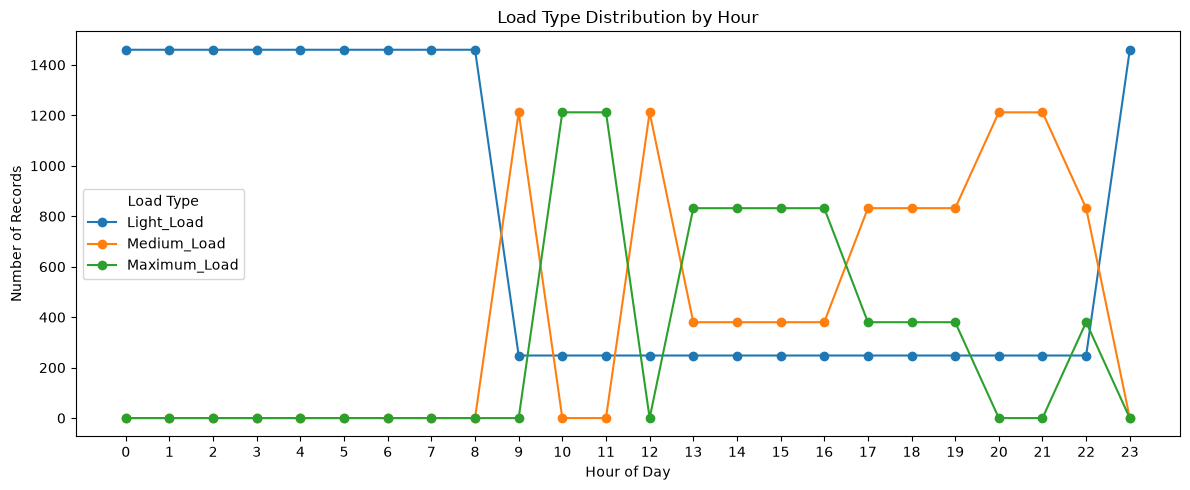

In [104]:
# Visualize load type counts by hour
fig, ax = plt.subplots(figsize=(12, 5))

hour_load.plot(kind="line", marker="o", ax=ax)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Records")
ax.set_title("Load Type Distribution by Hour")
ax.set_xticks(range(24))
ax.legend(title="Load Type")

plt.tight_layout()
plt.show()

### 7.9 Load Type Distribution by Day of Week

The distribution of load types is examined across the days of the week. This helps identify whether weekday and weekend patterns differ.

The `day_of_week` feature uses the standard convention where Monday is 0 and Sunday is 6.

In [105]:
# Create readable day names
day_names = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["day_name"] = df["day_of_week"].map(
    dict(enumerate(day_names))
)

# Count load types by day of week
day_load = pd.crosstab(
    df["day_name"],
    df["load_type"]
).reindex(day_names)

day_load

load_type,Light_Load,Medium_Load,Maximum_Load
day_name,,,
Monday,2288,1600,1200
Tuesday,2248,1568,1176
Wednesday,2248,1568,1176
Thursday,2192,1600,1200
Friday,2192,1600,1200
Saturday,2864,1216,912
Sunday,4040,544,408


### 7.10 Visualizing Load Type Distribution by Day of Week

The load-type distribution across the days of the week is visualized to highlight differences between weekdays and weekends.

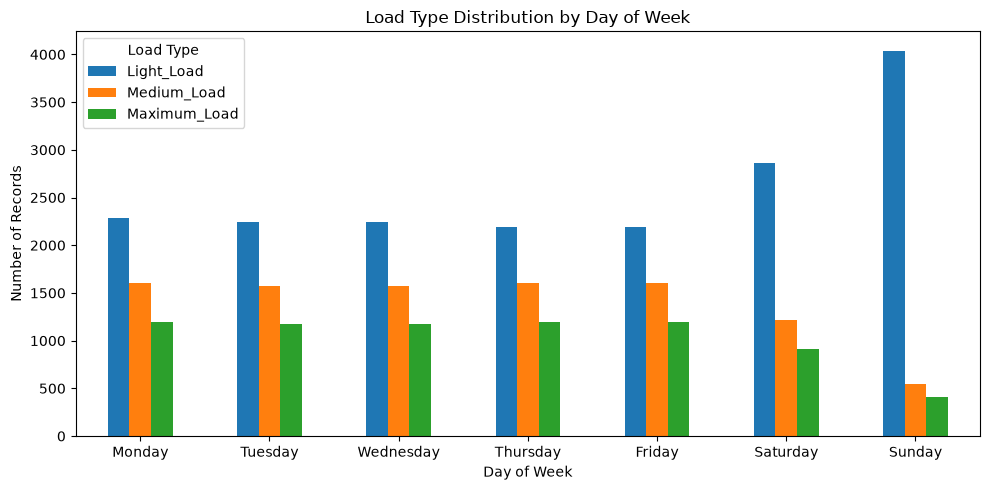

In [106]:
# Visualize load type counts by day of week
fig, ax = plt.subplots(figsize=(10, 5))

day_load.plot(kind="bar", ax=ax)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Records")
ax.set_title("Load Type Distribution by Day of Week")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Load Type")

plt.tight_layout()
plt.show()

### Monthly Load Type Counts

The distribution of load types is displayed by month as descriptive dataset exploration. December is included in this summary only; it is reserved as the final test period and is not used to make modelling decisions.

In [107]:
# Count load types by month
month_load = pd.crosstab(
    df["month"],
    df["load_type"]
).reindex(range(1, 13))

month_load.index = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_load

load_type,Light_Load,Medium_Load,Maximum_Load
Jan,1464,864,648
Feb,1624,608,456
Mar,1408,896,672
Apr,1368,864,648
May,1520,832,624
Jun,1480,800,600
Jul,1352,928,696
Aug,1688,736,552
Sep,1592,736,552
Oct,1464,864,648


### 7.11 Monthly Load Type Analysis

Monthly load-type patterns are shown here as descriptive dataset exploration.

December is reserved as the final test period. Its observations are not used for model training, preprocessing fitting, feature selection, hyperparameter selection, or model comparison. The December labels are shown here only as part of descriptive dataset exploration and are not used to make modelling decisions.

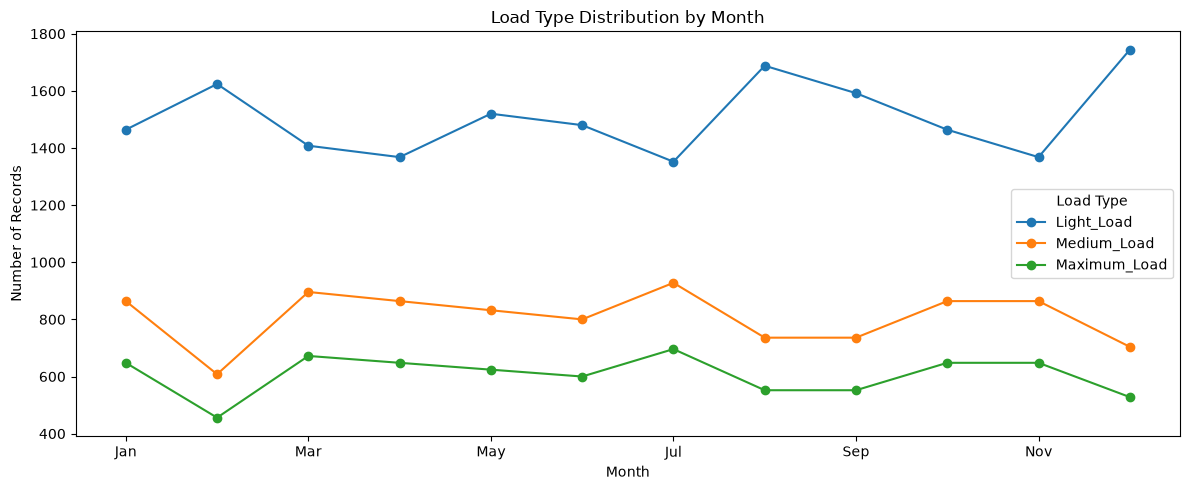

In [108]:
# Visualize load type distribution by month
fig, ax = plt.subplots(figsize=(12, 5))

month_load.plot(kind="line", marker="o", ax=ax)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Records")
ax.set_title("Load Type Distribution by Month")
ax.legend(title="Load Type")

plt.tight_layout()
plt.show()

In [109]:
# Correlation between numerical features
correlation_matrix = df[measurement_cols + pf_cols].corr()

correlation_matrix

,usage_kwh,lagging_reactive_kvarh,leading_reactive_kvarh,co2_tco2,lagging_power_factor,leading_power_factor
usage_kwh,1.000000,0.735151,-0.273042,0.828827,0.352710,0.330860
lagging_reactive_kvarh,0.735151,1.000000,-0.338393,0.737407,0.130420,0.380018
leading_reactive_kvarh,-0.273042,-0.338393,1.000000,-0.283229,0.485086,-0.865120
co2_tco2,0.828827,0.737407,-0.283229,1.000000,0.348177,0.339330
lagging_power_factor,0.352710,0.130420,0.485086,0.348177,1.000000,-0.525931
leading_power_factor,0.330860,0.380018,-0.865120,0.339330,-0.525931,1.000000


### 7.12 Correlation Analysis

The correlation matrix was examined to understand relationships among the numerical features.

A strong positive correlation is observed between `usage_kwh` and `co2_tco2` (approximately 0.83), as well as between `usage_kwh` and `lagging_reactive_kvarh` (approximately 0.74). A strong negative correlation is observed between `leading_reactive_kvarh` and `leading_power_factor` (approximately -0.87).

These relationships are expected because several electrical measurements are physically related. Correlated features are not removed automatically because different machine-learning models may use them differently. Feature usefulness will be evaluated through time-based validation during model selection.

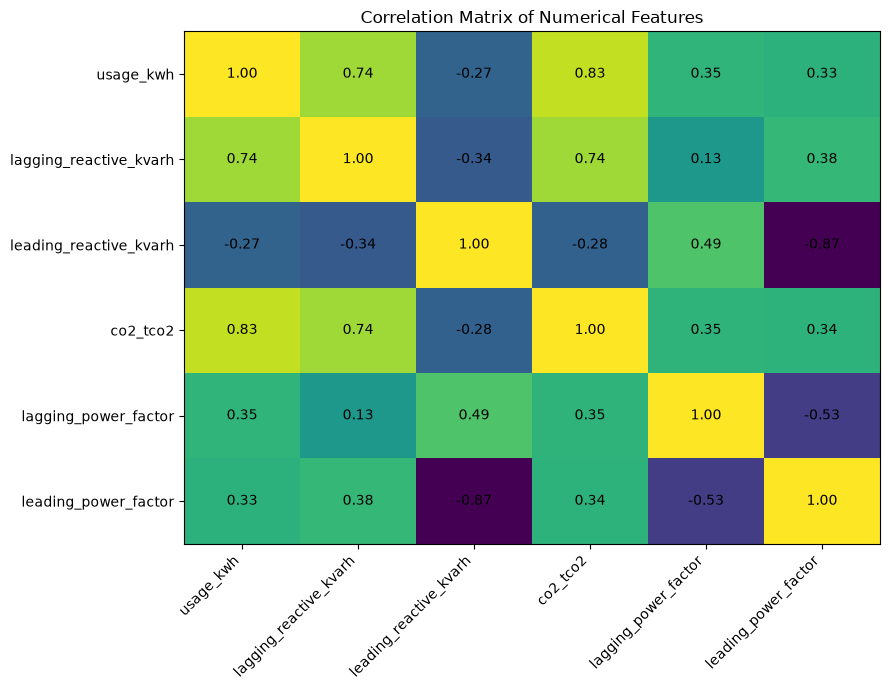

In [110]:
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    correlation_matrix,
    aspect="auto"
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## 8. Feature Engineering

The timestamp contains useful information about the daily and weekly patterns of electricity consumption. Instead of using the raw timestamp directly, time-based features are extracted.

The following features are created:

- `hour`: hour of the day
- `day_of_week`: day of the week
- `month`: month of the year
- `day`: day of the month
- `is_weekend`: whether the observation occurs on Saturday or Sunday
- `hour_sin` and `hour_cos`: cyclical representation of the hour
- `dow_sin` and `dow_cos`: cyclical representation of the day of the week

Cyclical encoding is used because, for example, 23:00 and 00:00 are close in time even though their numerical hour values are far apart.

No target information is used to create these features.

In [111]:
# Extract calendar/time features from the interval start timestamp
df["hour"] = df["interval_start"].dt.hour
df["day_of_week"] = df["interval_start"].dt.dayofweek
df["month"] = df["interval_start"].dt.month
df["day"] = df["interval_start"].dt.day

# Weekend indicator
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding of hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical encoding of day of week
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

print("Feature engineering completed.")

Feature engineering completed.


## 9. Time-Based Train/Test Split

Because this is time-series data, a random train-test split is not appropriate. The final month of the dataset, December 2018, is reserved as an unseen test set.

The model-development data consists of January through November 2018. December 2018 is kept completely separate and will only be used once for the final evaluation of the selected model.

This approach better reflects a real-world scenario where a model is trained on historical data and then used to predict future observations.

In [112]:
# Separate December 2018 as the final unseen test set
test_mask = df["interval_start"].dt.month == 12

dev_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

print("Development data:", len(dev_df))
print("Final test data:", len(test_df))

print("\nDevelopment period:")
print(dev_df["interval_start"].min(), "to", dev_df["interval_start"].max())

print("\nFinal test period:")
print(test_df["interval_start"].min(), "to", test_df["interval_start"].max())

Development data: 32064
Final test data: 2976

Development period:
2018-01-01 00:00:00 to 2018-11-30 23:45:00

Final test period:
2018-12-01 00:00:00 to 2018-12-31 23:45:00


In [113]:
feature_preview = df[
    [
        "interval_start",
        "hour",
        "day_of_week",
        "month",
        "day",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    ]
]

feature_preview.head(10)

,interval_start,hour,day_of_week,month,day,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,2018-01-01 00:00:00,0,0,1,1,0,0.000000,1.000000,0.0,1.0
1,2018-01-01 00:15:00,0,0,1,1,0,0.000000,1.000000,0.0,1.0
2,2018-01-01 00:30:00,0,0,1,1,0,0.000000,1.000000,0.0,1.0
3,2018-01-01 00:45:00,0,0,1,1,0,0.000000,1.000000,0.0,1.0
4,2018-01-01 01:00:00,1,0,1,1,0,0.258819,0.965926,0.0,1.0
5,2018-01-01 01:15:00,1,0,1,1,0,0.258819,0.965926,0.0,1.0
6,2018-01-01 01:30:00,1,0,1,1,0,0.258819,0.965926,0.0,1.0
7,2018-01-01 01:45:00,1,0,1,1,0,0.258819,0.965926,0.0,1.0
8,2018-01-01 02:00:00,2,0,1,1,0,0.500000,0.866025,0.0,1.0
9,2018-01-01 02:15:00,2,0,1,1,0,0.500000,0.866025,0.0,1.0


In [114]:
print("December records in development data:",
      (dev_df["interval_start"].dt.month == 12).sum())

print("December records in final test data:",
      (test_df["interval_start"].dt.month == 12).sum())

assert (dev_df["interval_start"].dt.month != 12).all()
assert (test_df["interval_start"].dt.month == 12).all()

print("\nSplit verified successfully.")

December records in development data: 0
December records in final test data: 2976

Split verified successfully.


## 10. Time-Based Train/Validation Split

The January–November development data is further divided chronologically into training and validation sets.

- January–September 2018: training data
- October–November 2018: validation data
- December 2018: final unseen test data

The validation period occurs after the training period, which avoids using future observations to predict the past.

The validation set will be used for model comparison and selection. The December test set will remain untouched until the final evaluation.

In [115]:
# Create chronological training and validation sets
train_mask = dev_df["interval_start"] < pd.Timestamp("2018-10-01")

train_df = dev_df.loc[train_mask].copy()
val_df = dev_df.loc[~train_mask].copy()

print("Training data:", len(train_df))
print("Validation data:", len(val_df))
print("Final test data:", len(test_df))

print("\nTraining period:")
print(train_df["interval_start"].min(), "to", train_df["interval_start"].max())

print("\nValidation period:")
print(val_df["interval_start"].min(), "to", val_df["interval_start"].max())

print("\nFinal test period:")
print(test_df["interval_start"].min(), "to", test_df["interval_start"].max())

Training data: 26208
Validation data: 5856
Final test data: 2976

Training period:
2018-01-01 00:00:00 to 2018-09-30 23:45:00

Validation period:
2018-10-01 00:00:00 to 2018-11-30 23:45:00

Final test period:
2018-12-01 00:00:00 to 2018-12-31 23:45:00


In [116]:
# Verify chronological separation
assert train_df["interval_start"].max() < val_df["interval_start"].min()
assert val_df["interval_start"].max() < test_df["interval_start"].min()

# Verify that December is completely isolated
assert (train_df["interval_start"].dt.month != 12).all()
assert (val_df["interval_start"].dt.month != 12).all()
assert (test_df["interval_start"].dt.month == 12).all()

print("Time-based split verified successfully.")

Time-based split verified successfully.


## 11. Define Features and Target

The target variable is `load_type`, which contains the three load categories:

* `Light_Load`
* `Medium_Load`
* `Maximum_Load`

The input features consist of the electrical measurements and engineered time-based features.

The raw timestamp and text-based date columns are not used directly because useful time information has already been extracted into numerical features.

The same feature set is used for training, validation, and final testing.

In [117]:
feature_cols = [
    "usage_kwh",
    "lagging_reactive_kvarh",
    "leading_reactive_kvarh",
    "co2_tco2",
    "lagging_power_factor",
    "leading_power_factor",
    "nsm",
    "hour",
    "day_of_week",
    "month",
    "day",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

target_col = "load_type"

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(str).copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].astype(str).copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(str).copy()

print("Number of features:", len(feature_cols))
print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Test features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().reindex(LOAD_ORDER))

print("\nMissing values in training features:")
print(X_train.isna().sum())

Number of features: 16
Training features: (26208, 16)
Validation features: (5856, 16)
Test features: (2976, 16)

Training target distribution:
load_type
Light_Load      13496
Medium_Load      7264
Maximum_Load     5448
Name: count, dtype: int64

Missing values in training features:
usage_kwh                 1128
lagging_reactive_kvarh     648
leading_reactive_kvarh     863
co2_tco2                   346
lagging_power_factor      2675
leading_power_factor      3102
nsm                          0
hour                         0
day_of_week                  0
month                        0
day                          0
is_weekend                   0
hour_sin                     0
hour_cos                     0
dow_sin                      0
dow_cos                      0
dtype: int64


The `X` variables contain predictor features, while the `y` variables contain the target load type. Separate feature and target variables are created for training, validation, and final testing using the same feature list.

## 12. Data Preprocessing

The dataset contains missing values in several numerical features.

Missing values are handled using median imputation. The imputer is placed inside the scikit-learn pipeline so that the median values are learned only from the training data.

For models that benefit from feature scaling, standardization is applied after imputation.

This prevents information from the validation or final test period from being used during preprocessing.

In [118]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

scaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


In [119]:
# Verify that the training data contains missing values
print("Total missing training values:", X_train.isna().sum().sum())
print("Total missing validation values:", X_val.isna().sum().sum())
print("Total missing test values:", X_test.isna().sum().sum())

Total missing training values: 8762
Total missing validation values: 1959
Total missing test values: 1055


The pipelines perform imputation automatically during model fitting and prediction. Since each model pipeline is fitted on the training data, the validation and test sets do not influence the learned imputation values. Scaling is included only in the pipeline used for models that benefit from it.

## 13. Evaluation Metrics

The models are evaluated using:

* Accuracy
* Macro Precision
* Macro Recall
* Macro F1-score

Macro F1 is the primary metric because it gives equal importance to each load class despite the class imbalance.

The final evaluation will also include a classification report and confusion matrix.

In [120]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

def evaluate_model(model, X, y, dataset_name="Validation"):
    predictions = model.predict(X)

    metrics = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y, predictions),
        "Macro Precision": precision_score(
            y, predictions, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y, predictions, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y, predictions, average="macro", zero_division=0
        ),
    }

    return metrics, predictions

## 14. Baseline Model

A simple Logistic Regression model is used as a baseline.

Logistic Regression provides a useful reference point before comparing it with tree-based models.

Class-balanced weighting is used because the target classes are not equally represented.

In [121]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )),
])

baseline_model.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_model(
    baseline_model,
    X_val,
    y_val,
    "Validation"
)

baseline_metrics

{'Dataset': 'Validation',
 'Accuracy': 0.7581967213114754,
 'Macro Precision': 0.7249977143099694,
 'Macro Recall': 0.7309670781893004,
 'Macro F1': 0.7259235345047123}

In [122]:
print("Baseline Classification Report:\n")
print(
    classification_report(
        y_val,
        baseline_predictions,
        labels=LOAD_ORDER,
        zero_division=0
    )
)

Baseline Classification Report:

              precision    recall  f1-score   support

  Light_Load       0.96      0.85      0.90      2832
 Medium_Load       0.60      0.66      0.63      1728
Maximum_Load       0.62      0.68      0.65      1296

    accuracy                           0.76      5856
   macro avg       0.72      0.73      0.73      5856
weighted avg       0.78      0.76      0.77      5856



## 15. Decision Tree Classifier

A Decision Tree is tested because it can capture non-linear relationships between electrical measurements and time-based features.

The model uses class-balanced weights to reduce the effect of class imbalance.

In [123]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    )),
])

decision_tree_model.fit(X_train, y_train)

dt_metrics, dt_predictions = evaluate_model(
    decision_tree_model,
    X_val,
    y_val,
    "Validation"
)

dt_metrics

{'Dataset': 'Validation',
 'Accuracy': 0.7967896174863388,
 'Macro Precision': 0.7564057602426194,
 'Macro Recall': 0.7505656256539025,
 'Macro F1': 0.7519685316991384}

## 16. Random Forest Classifier

Random Forest is evaluated as an ensemble of decision trees.

It can model non-linear relationships and interactions between features while generally being more robust than a single decision tree.

Class-balanced weighting is used because the target classes are imbalanced.

In [124]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
])

random_forest_model.fit(X_train, y_train)

rf_metrics, rf_predictions = evaluate_model(
    random_forest_model,
    X_val,
    y_val,
    "Validation"
)

rf_metrics

{'Dataset': 'Validation',
 'Accuracy': 0.8335040983606558,
 'Macro Precision': 0.7890632900452926,
 'Macro Recall': 0.7915881983678593,
 'Macro F1': 0.7901793209942545}

## 17. HistGradientBoosting Classifier

HistGradientBoosting is another non-linear ensemble model.

It builds trees sequentially, where each new tree attempts to improve the errors made by the previous trees.

It is included as a stronger candidate for comparison with Logistic Regression, Decision Tree, and Random Forest.

In [125]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gradient_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    )),
])

hist_gradient_model.fit(X_train, y_train)

hgb_metrics, hgb_predictions = evaluate_model(
    hist_gradient_model,
    X_val,
    y_val,
    "Validation"
)

hgb_metrics

{'Dataset': 'Validation',
 'Accuracy': 0.8353825136612022,
 'Macro Precision': 0.7903062244724167,
 'Macro Recall': 0.7904765641347562,
 'Macro F1': 0.7903680851509759}

## 18. Model Comparison

The validation results from all candidate models are compared using the same time-based validation set.

Macro F1 is used as the primary selection criterion.

In [126]:
results = pd.DataFrame([
    {"Model": "Logistic Regression", **baseline_metrics},
    {"Model": "Decision Tree", **dt_metrics},
    {"Model": "Random Forest", **rf_metrics},
    {"Model": "HistGradientBoosting", **hgb_metrics},
])

results = results.drop(columns=["Dataset"])

results = results.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,HistGradientBoosting,0.835383,0.790306,0.790477,0.790368
1,Random Forest,0.833504,0.789063,0.791588,0.790179
2,Decision Tree,0.796790,0.756406,0.750566,0.751969
3,Logistic Regression,0.758197,0.724998,0.730967,0.725924


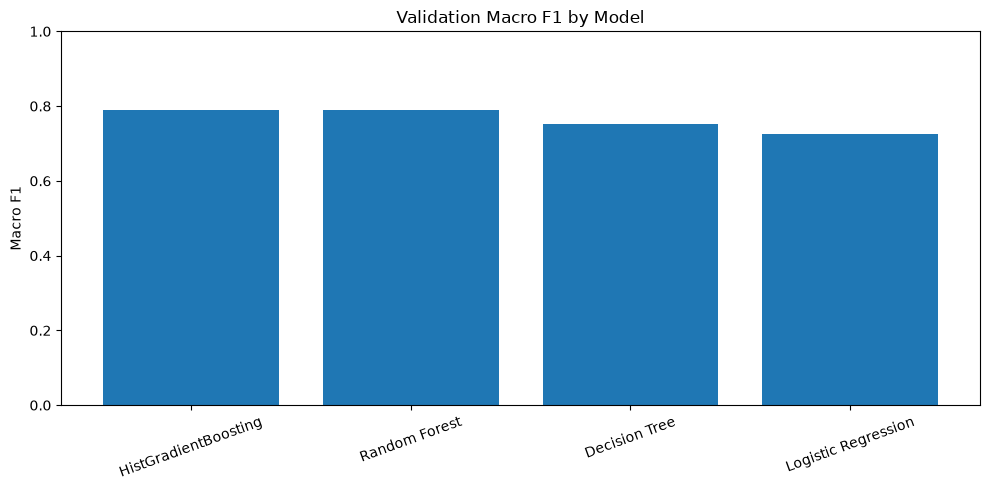

In [127]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    results["Model"],
    results["Macro F1"]
)

ax.set_title("Validation Macro F1 by Model")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

The model with the highest validation Macro F1 is selected. Accuracy is also reported, but it is not used alone for selection because it can understate errors on less frequent classes.

## 19. Best Model Selection

The model with the highest validation Macro F1-score is selected for final training.

The December 2018 test set has not been used during model comparison.

In [128]:
best_model_name = results.loc[0, "Model"]

model_objects = {
    "Logistic Regression": baseline_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "HistGradientBoosting": hist_gradient_model,
}

best_model = model_objects[best_model_name]

print("Selected model:", best_model_name)
print("Validation Macro F1:", results.loc[0, "Macro F1"])

Selected model: HistGradientBoosting
Validation Macro F1: 0.7903680851509759


In [129]:
print("Validation performance of selected model:\n")

selected_metrics = results.iloc[0]
print(selected_metrics.to_string())

Validation performance of selected model:

Model              HistGradientBoosting
Accuracy                       0.835383
Macro Precision                0.790306
Macro Recall                   0.790477
Macro F1                       0.790368


## 20. Validation Classification Report

The selected model is examined using class-level precision, recall, and F1-score.

This helps identify whether the model performs well across all three load categories rather than only the majority class.

In [130]:
best_val_predictions = best_model.predict(X_val)

print(
    classification_report(
        y_val,
        best_val_predictions,
        labels=LOAD_ORDER,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Light_Load       0.98      0.98      0.98      2832
 Medium_Load       0.74      0.72      0.73      1728
Maximum_Load       0.66      0.67      0.66      1296

    accuracy                           0.84      5856
   macro avg       0.79      0.79      0.79      5856
weighted avg       0.84      0.84      0.84      5856



## 21. Validation Confusion Matrix

A confusion matrix shows how observations from each actual load class are classified by the selected model.

Correct predictions appear on the diagonal, while misclassifications appear outside the diagonal.

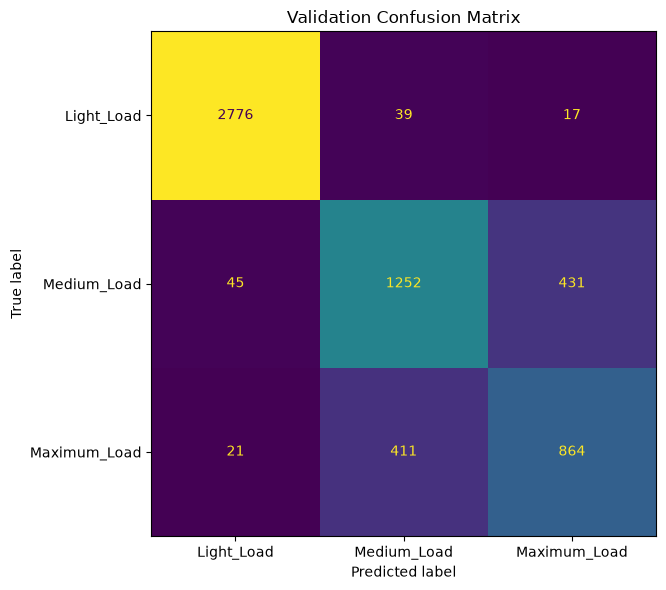

In [131]:
cm = confusion_matrix(
    y_val,
    best_val_predictions,
    labels=LOAD_ORDER
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LOAD_ORDER
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("Validation Confusion Matrix")

plt.tight_layout()
plt.show()

## 22. Per-Class Performance

The classification report is converted into a table to compare precision, recall, and F1-score for each load category.

In [132]:
report_dict = classification_report(
    y_val,
    best_val_predictions,
    labels=LOAD_ORDER,
    output_dict=True,
    zero_division=0
)

per_class_results = pd.DataFrame(report_dict).T

per_class_results.loc[
    LOAD_ORDER,
    ["precision", "recall", "f1-score", "support"]
]

,precision,recall,f1-score,support
Light_Load,0.976777,0.980226,0.978498,2832.0
Medium_Load,0.735605,0.724537,0.730029,1728.0
Maximum_Load,0.658537,0.666667,0.662577,1296.0


In [133]:
validation_class_f1 = per_class_results.loc[LOAD_ORDER, "f1-score"]
print(
    f"On validation, {validation_class_f1.idxmax()} has the highest class F1 "
    f"({validation_class_f1.max():.3f}) and {validation_class_f1.idxmin()} "
    f"has the lowest ({validation_class_f1.min():.3f})."
)

On validation, Light_Load has the highest class F1 (0.978) and Maximum_Load has the lowest (0.663).


## 23. Feature Importance

Feature importance is examined when supported by the selected tree-based model.

This helps identify which input variables contributed most to the model's predictions.

In [134]:
selected_estimator = best_model.named_steps["model"]

if hasattr(selected_estimator, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": selected_estimator.feature_importances_,
    }).sort_values(
        "Importance",
        ascending=False
    )

    display(feature_importance)

    top_features = feature_importance.head(15).sort_values(
        "Importance",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    ax.set_xlabel("Importance")
    ax.set_title("Top Feature Importances")

    plt.tight_layout()
    plt.show()

else:
    print(
        "The selected model does not provide tree-based "
        "feature_importances_."
    )

The selected model does not provide tree-based feature_importances_.


Feature importance indicates which variables the fitted model used more heavily; it does not show that a feature causes the target.

## 24. Final Model Training

After selecting the best model using January–September training data and October–November validation data, the selected model is retrained using all available development data from January through November 2018.

The December 2018 data remains completely unseen until the final evaluation.

The preprocessing pipeline is fitted again on the complete development data only.

In [135]:
X_dev = dev_df[feature_cols].copy()
y_dev = dev_df[target_col].astype(str).copy()

print("Development feature matrix:", X_dev.shape)
print("Development target vector:", y_dev.shape)
print("Final test feature matrix:", X_test.shape)
print("Final test target vector:", y_test.shape)

Development feature matrix: (32064, 16)
Development target vector: (32064,)
Final test feature matrix: (2976, 16)
Final test target vector: (2976,)


In [136]:
best_model.fit(X_dev, y_dev)

print("Final model retrained on January-November 2018 data.")

Final model retrained on January-November 2018 data.


## 25. Final Test Evaluation — December 2018

The December 2018 dataset is now used for the first and only final evaluation of the selected model.

This dataset was not used for training, preprocessing fitting, model comparison, or model selection.

The following metrics are reported:

* Accuracy
* Macro Precision
* Macro Recall
* Macro F1-score

In [137]:
final_metrics, final_predictions = evaluate_model(
    best_model,
    X_test,
    y_test,
    "December 2018 Test"
)

final_metrics

{'Dataset': 'December 2018 Test',
 'Accuracy': 0.9092741935483871,
 'Macro Precision': 0.8812926141497172,
 'Macro Recall': 0.9457534056157909,
 'Macro F1': 0.9062096193787132}

In [138]:
print("Final Test Classification Report:\n")

print(
    classification_report(
        y_test,
        final_predictions,
        labels=LOAD_ORDER,
        zero_division=0
    )
)

Final Test Classification Report:

              precision    recall  f1-score   support

  Light_Load       1.00      0.85      0.92      1744
 Medium_Load       0.82      1.00      0.90       704
Maximum_Load       0.83      0.99      0.90       528

    accuracy                           0.91      2976
   macro avg       0.88      0.95      0.91      2976
weighted avg       0.92      0.91      0.91      2976



## 26. Final Test Confusion Matrix

The final confusion matrix shows how the selected model classified the December 2018 observations across the three load categories.

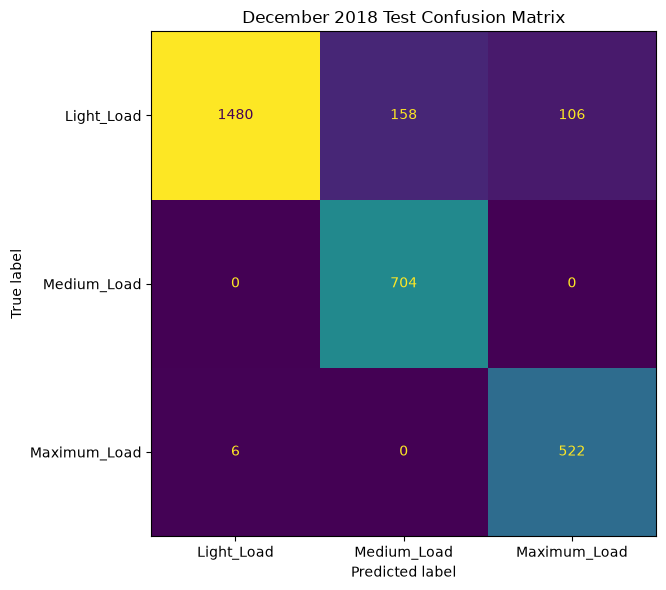

In [139]:
final_cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=LOAD_ORDER
)

fig, ax = plt.subplots(figsize=(7, 6))

final_disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=LOAD_ORDER
)

final_disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("December 2018 Test Confusion Matrix")

plt.tight_layout()
plt.show()

## 27. Final Test Per-Class Results

The final classification report is converted into a table so that performance can be examined separately for Light, Medium, and Maximum load categories.

In [140]:
final_report_dict = classification_report(
    y_test,
    final_predictions,
    labels=LOAD_ORDER,
    output_dict=True,
    zero_division=0
)

final_per_class_results = pd.DataFrame(final_report_dict).T

final_per_class_results.loc[
    LOAD_ORDER,
    ["precision", "recall", "f1-score", "support"]
]

,precision,recall,f1-score,support
Light_Load,0.995962,0.848624,0.916409,1744.0
Medium_Load,0.816705,1.000000,0.899106,704.0
Maximum_Load,0.831210,0.988636,0.903114,528.0


## 28. Final Performance Summary

The final performance of the selected model on the unseen December 2018 test set is summarized below.

In [141]:
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
    ],
    "Score": [
        final_metrics["Accuracy"],
        final_metrics["Macro Precision"],
        final_metrics["Macro Recall"],
        final_metrics["Macro F1"],
    ],
})

final_summary

,Metric,Score
0,Accuracy,0.909274
1,Macro Precision,0.881293
2,Macro Recall,0.945753
3,Macro F1,0.906210


In [142]:
print(f"Selected model: {best_model_name}")
print(f"Final Test Accuracy: {final_metrics['Accuracy']:.4f}")
print(f"Final Test Macro Precision: {final_metrics['Macro Precision']:.4f}")
print(f"Final Test Macro Recall: {final_metrics['Macro Recall']:.4f}")
print(f"Final Test Macro F1: {final_metrics['Macro F1']:.4f}")

Selected model: HistGradientBoosting
Final Test Accuracy: 0.9093
Final Test Macro Precision: 0.8813
Final Test Macro Recall: 0.9458
Final Test Macro F1: 0.9062


## 29. Conclusion

This project developed a machine-learning classification pipeline for predicting power system load type from 15-minute electrical measurements and time-based features.

The dataset was cleaned and validated before modelling. Missing numerical values were handled using training-only median imputation within scikit-learn pipelines. Invalid power-factor values were treated as missing, and the NSM feature was corrected deterministically using the recorded timestamp.

A time-aware validation strategy was used to avoid future-data leakage:

* **January–September 2018:** Training
* **October–November 2018:** Validation
* **December 2018:** Final unseen test

Multiple classification models were evaluated using the same validation period. **Macro F1-score** was used as the primary model-selection metric because the target classes are imbalanced and performance across all three load categories is important.

The **HistGradientBoosting** model achieved the highest validation Macro F1-score, although its performance was very close to the Random Forest model. The selected model was then retrained using the complete January–November 2018 development data.

The final model was evaluated once on the completely unseen **December 2018** test set and achieved:

* **Accuracy:** 90.93%
* **Macro Precision:** 88.13%
* **Macro Recall:** 94.58%
* **Macro F1:** 90.62%

The results indicate that the model can effectively distinguish between **Light_Load, Medium_Load, and Maximum_Load** categories. The time-based splitting and training-only preprocessing help ensure that the reported test performance is based on data that was not used during model development.

Overall, this project demonstrates a complete machine-learning workflow covering data cleaning, exploratory analysis, feature engineering, time-aware validation, model comparison, and final evaluation on an unseen test period.


In [143]:
print("FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"Selected Model: {best_model_name}")
print(f"Training Records: {len(train_df):,}")
print(f"Validation Records: {len(val_df):,}")
print(f"Development Records Used for Final Training: {len(dev_df):,}")
print(f"Final Test Records: {len(test_df):,}")
print("-" * 60)
print(f"Accuracy:        {final_metrics['Accuracy']:.4f}")
print(f"Macro Precision: {final_metrics['Macro Precision']:.4f}")
print(f"Macro Recall:    {final_metrics['Macro Recall']:.4f}")
print(f"Macro F1:        {final_metrics['Macro F1']:.4f}")
print("=" * 60)

FINAL PROJECT SUMMARY
Selected Model: HistGradientBoosting
Training Records: 26,208
Validation Records: 5,856
Development Records Used for Final Training: 32,064
Final Test Records: 2,976
------------------------------------------------------------
Accuracy:        0.9093
Macro Precision: 0.8813
Macro Recall:    0.9458
Macro F1:        0.9062


## 30. Notebook Quality Checks

> December 2018 was kept separate from model development and was used only for the final evaluation after model selection.

In [144]:
assert len(train_df) == 26208
assert len(val_df) == 5856
assert len(test_df) == 2976

assert train_df["interval_start"].max() < val_df["interval_start"].min()
assert val_df["interval_start"].max() < test_df["interval_start"].min()

assert (test_df["interval_start"].dt.month == 12).all()

assert set(feature_cols).isdisjoint({target_col})

assert "date_time" not in feature_cols
assert "timestamp" not in feature_cols
assert "interval_start" not in feature_cols
assert "day_name" not in feature_cols

print("All final notebook quality checks passed.")

All final notebook quality checks passed.
